# PC-Well Amplitude/Shape Self-Calibration -- Before/After

Validates the cheapest of the three PC-well calibration ideas discussed: pc_ttp
already re-anchors the **time** axis using each chip's PC well TTP. This notebook
checks whether also re-calibrating **amplitude/shape** -- fitting a per-chip affine
transform that maps that chip's own PC well curve onto a reference PC shape (the
mean PC shape across the *other* chips), then applying that same transform to every
other curve on the chip -- further reduces cross-chip divergence beyond pc_ttp alone.

No retraining, no gradients: pure preprocessing, computed fresh per chip from the PC
well every chip already has. This does **not** modify any existing `.py` file --
it imports `04_cross_dataset_training.py` as-is (same pattern as
`20260813-pc_ttp_alignment_validation.ipynb`) and does the calibration entirely here.

Motivation: the earlier `plot_target_across_chips` sweep showed real cross-chip shape
divergence for `Kp`/`IBV` even *after* pc_ttp alignment -- this notebook checks whether
amplitude/shape is the (or a) remaining factor, before considering more chip data.

**Curve type**: `ori_curve_wavelet_bior35_norm` is already per-curve min-max
normalized *on disk*, and `combine_group_pc_aligned` re-normalizes it *again* after
truncation. Fitting the calibration on a curve that's already been squashed to [0,1]
twice would understate any real amplitude/gain difference between chips -- most of
that signal is gone before calibration ever sees it. So the calibration below is
fit on `ori_curve_wavelet_bior35` (denoised, **not** normalized), with normalization
applied exactly once, as the *last* step -- same "normalize after truncation"
principle already used for pc_ttp, extended to "normalize after calibration" too.
Wavelet denoising itself is kept (it smooths noise, it doesn't rescale amplitude,
so it isn't a confound the same way early normalization is). The BEFORE plot still
uses `ori_curve_wavelet_bior35_norm` since that's what production actually runs
today -- so BEFORE/AFTER stay a fair comparison against the real baseline.

In [14]:
import os
import importlib
import colorsys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(os.path.dirname(notebook_path))
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

# Import-only -- 04_cross_dataset_training.py itself is never modified.
cdt = importlib.import_module("04_cross_dataset_training")

%matplotlib inline

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configuration

In [15]:
GROUP_NAME = "final_4_chip_clean"
EXP_FOLDER = config.FINAL_EXP_FOLDER + "_nc_subtract"
CURVE_TYPE_NORM = "ori_curve_wavelet_bior35_norm"   # today's production curve_type -- for BEFORE
CURVE_TYPE_RAW  = "ori_curve_wavelet_bior35"        # denoised, NOT normalized -- for fitting/applying calibration
ANCHOR_METHOD = "min"   # "min" | "percentile" -- must match a pc_ttp run already cached

folder_names = config.CROSS_DATASET_GROUPS[GROUP_NAME]
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]
HELD_OUT_CHIP = folder_names[0]   # simulates "new chip at inference" for the pc_ttp anchor

def short_name(folder):
    return folder.split('_U_', 1)[1]

print(f"Group '{GROUP_NAME}' -> {len(folder_names)} chips:")
for n in folder_names:
    print(" -", n, f"({short_name(n)})")

Group 'final_4_chip_clean' -> 4 chips:
 - D20260806_E00_C00_F4500KHz_U_DDM_01_06 (DDM_01_06)
 - D20260807_E00_C00_F4500KHz_U_DDM_02_07 (DDM_02_07)
 - D20260808_E00_C00_F4500KHz_U_DDM_03_01 (DDM_03_01)
 - D20260810_E00_C00_F4500KHz_U_DDM_04_01 (DDM_04_01)


## 2. Build the pc_ttp-aligned pools, merge PC wells back in

Two pools, both pc_ttp-aligned the same way (same anchor/common_duration logic),
differing only in curve_type:
- `pool_norm` (`..._norm`): today's actual production output -- used for BEFORE.
- `pool_raw` (no `_norm`): denoised but not normalized -- used to fit and apply
  calibration, since amplitude information needs to still be present for that to
  mean anything.

`combine_group_pc_aligned` excludes PC from its returned pool (PC is only used
internally to compute the anchor) -- `merge_pc_into_pool` replays the exact same
shift -> truncate -> resample (and, for `_norm` curve_types, normalize) steps the
main curves went through, reusing the recipe/resampler `combine_group_pc_aligned`
already computed, so no alignment logic is duplicated.

In [16]:
pc_ttp_cache_dir = Path(EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME / "_cache_pc_ttp"
pc_ttp_cache_dir.mkdir(parents=True, exist_ok=True)


def build_pool(curve_type):
    combined = cdt.combine_group_pc_aligned(
        exp_paths, GROUP_NAME, curve_type=curve_type, held_out_chip=HELD_OUT_CHIP,
        anchor_method=ANCHOR_METHOD, anchor_pct=10, pc_ttp_cache_dir=pc_ttp_cache_dir)
    print(f"[{curve_type}] pool curves shape:", combined["curves"].shape)
    return combined


def merge_pc_into_pool(combined, exp_paths, curve_type):
    recipe = combined["pc_ttp_recipe"]
    anchor, common_duration, pc_ttp = recipe["anchor"], recipe["common_duration"], recipe["pc_ttp_per_chip"]
    resampler = combined["resampler"]

    pc_curves_all, pc_dataset_id, pc_well_ids = [], [], []
    for exp_path in exp_paths:
        pc = cdt.load_pc_wells_snapshot(exp_path, curve_type)
        if pc is None:
            continue
        chip_name = exp_path.name
        ttp = pc_ttp.get(chip_name)
        t2, c2, shift = cdt.shift_to_pc_ttp_anchor(pc["timestamps"], pc["curves"], ttp, anchor)
        t3, c3 = cdt.truncate_to_common_duration(t2, c2, common_duration)
        c4 = resampler.transform(t3, c3)
        if curve_type.endswith("_norm"):
            c4 = cdt.normalize_curves_minmax(c4)
        pc_curves_all.append(c4)
        pc_dataset_id.append(np.full(len(c4), chip_name, dtype=object))
        pc_well_ids.append(np.full(len(c4), f"{chip_name}::PC", dtype=object))

    pc_curves_all = np.concatenate(pc_curves_all, axis=0)
    pc_dataset_id = np.concatenate(pc_dataset_id, axis=0)
    pc_well_ids = np.concatenate(pc_well_ids, axis=0)
    pc_y = np.full(len(pc_curves_all), "PC", dtype=object)

    pc_conc = np.full(len(pc_curves_all), None, dtype=object)

    merged = dict(combined)
    merged["curves"] = np.concatenate([combined["curves"], pc_curves_all], axis=0)
    merged["Y_mapped"] = np.concatenate([combined["Y_mapped"], pc_y], axis=0)
    merged["dataset_id"] = np.concatenate([combined["dataset_id"], pc_dataset_id], axis=0)
    if combined.get("well_ids") is not None:
        merged["well_ids"] = np.concatenate([combined["well_ids"], pc_well_ids], axis=0)
    if combined.get("concentration_raw") is not None:
        merged["concentration_raw"] = np.concatenate([combined["concentration_raw"], pc_conc], axis=0)
    return merged


pool_norm = merge_pc_into_pool(build_pool(CURVE_TYPE_NORM), exp_paths, CURVE_TYPE_NORM)
pool_raw  = merge_pc_into_pool(build_pool(CURVE_TYPE_RAW),  exp_paths, CURVE_TYPE_RAW)
print(pd.Series(pool_raw["Y_mapped"]).value_counts())

  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] EXCLUDE_WELL_MAPPING: dropping 3745 samples from wells [6, 7, 8] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] EXCLUDE_WELL_MAPPING: dropping 1928 samples from wells [6, 8] (y_label={6: 'Cov', 8: 'PC'}, y_concentration={6: '1e+04', 8: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01
  [PC-TTP align] anchor (min) = 93.17 | held_out=D20260806_E00_C00_F4500KHz_U_DDM_01_06
    D20260806_E00_C00_F4500KHz_U_DDM_01_06: shift=  241.43
    D20260807_E00_C00_F4500KHz_U_DDM_02_07: shift=  347.47
    D20260808_E00_C00_F4500KHz_U_DDM_03_01: shift=  401.69
    D20260810_E00_C00_F4500KHz_U_

## 3. Plotting helpers (reused from `20260813-pc_ttp_alignment_validation.ipynb`, unmodified)

In [17]:
def build_well_table(combined):
    df = pd.DataFrame({
        "well_id": combined["well_ids"],
        "dataset_id": combined["dataset_id"],
        "label": combined["Y_mapped"],
    })
    df["row_idx"] = np.arange(len(df))
    meta = df.groupby("well_id").agg(dataset_id=("dataset_id", "first"), label=("label", "first"))
    row_idx_map = df.groupby("well_id")["row_idx"].apply(np.array)
    wells = meta.join(row_idx_map.rename("row_idx")).reset_index()
    wells["n_pixels"] = wells["row_idx"].apply(len)
    return wells


def _shade(base_rgb, frac, spread=0.3):
    h, l, s = colorsys.rgb_to_hls(*base_rgb[:3])
    l = min(0.85, max(0.15, l + (frac - 0.5) * spread))
    return colorsys.hls_to_rgb(h, l, s)


def _exp_colors(exp_names):
    cmap_exp = plt.cm.tab10
    return {n: cmap_exp(i % 10) for i, n in enumerate(exp_names)}


def _exp_legend(fig, exp_color, exp_names, y_anchor=-0.02):
    handles = [plt.Line2D([0], [0], color=exp_color[n], lw=2, label=short_name(n))
               for n in exp_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(exp_names), 4),
               fontsize=8, bbox_to_anchor=(0.5, y_anchor), frameon=True)


def _raw_conc(combined, well_row):
    conc = combined.get("concentration_raw")
    if conc is None:
        return None
    val = conc[well_row["row_idx"][0]]
    try:
        return float(val)
    except (TypeError, ValueError):
        return None


def plot_target_across_chips(combined, label_order=None, figsize_per_cell=(6, 4),
                             title=None, alpha_indiv=0.10, with_all_curves=True,
                             sharey=False, y_scale=None):
    """Copied from 20260813-pc_ttp_alignment_validation.ipynb (unmodified)."""
    wells = build_well_table(combined)
    exp_names = sorted(wells["dataset_id"].unique())
    exp_color = _exp_colors(exp_names)

    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    if label_order is not None:
        all_labels = [l for l in label_order if l in labels_seen]
        all_labels += [l for l in labels_seen if l not in all_labels]
    else:
        nc    = [l for l in labels_seen if str(l).startswith("NC")]
        nonnc = [l for l in labels_seen if not str(l).startswith("NC")]
        all_labels = sorted(nonnc) + sorted(nc)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(all_labels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]),
                             squeeze=False, sharey="row" if sharey else False)
    axes = axes[0]

    for ax, label in zip(axes, all_labels):
        label_wells = wells[wells["label"] == label].copy()
        label_wells["_conc"] = [_raw_conc(combined, w) for _, w in label_wells.iterrows()]
        concs_sorted = sorted({c for c in label_wells["_conc"] if c is not None})
        n_concs = len(concs_sorted)

        for _, w in label_wells.iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]
            mean = curves.mean(axis=0)
            conc = w["_conc"]
            frac = (concs_sorted.index(conc) / (n_concs - 1)) if (conc is not None and n_concs > 1) else 0.5
            color = _shade(exp_color[w["dataset_id"]], 1 - frac)

            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.4, alpha=alpha_indiv, rasterized=True)
            ax.plot(t, mean, color=color, lw=1.5)

        ax.set_title(str(label), fontsize=11, fontweight="bold")
        ax.set_xlabel("Time", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.tick_params(labelsize=7)
        if y_scale is not None:
            ax.set_ylim(*y_scale)

    axes[0].set_ylabel("Signal", fontsize=9)
    fig.suptitle(title or "Same target across chips  (colour=chip, shade=concentration)",
                fontsize=12, fontweight="bold")
    _exp_legend(fig, exp_color, exp_names)
    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.show()

print("Plotting helpers defined.")

Plotting helpers defined.


## 4. BEFORE -- today's actual production pipeline (pc_ttp aligned, `_norm` curve_type)

No calibration -- this is `pool_norm` exactly as `04_cross_dataset_training.py`
produces it today.

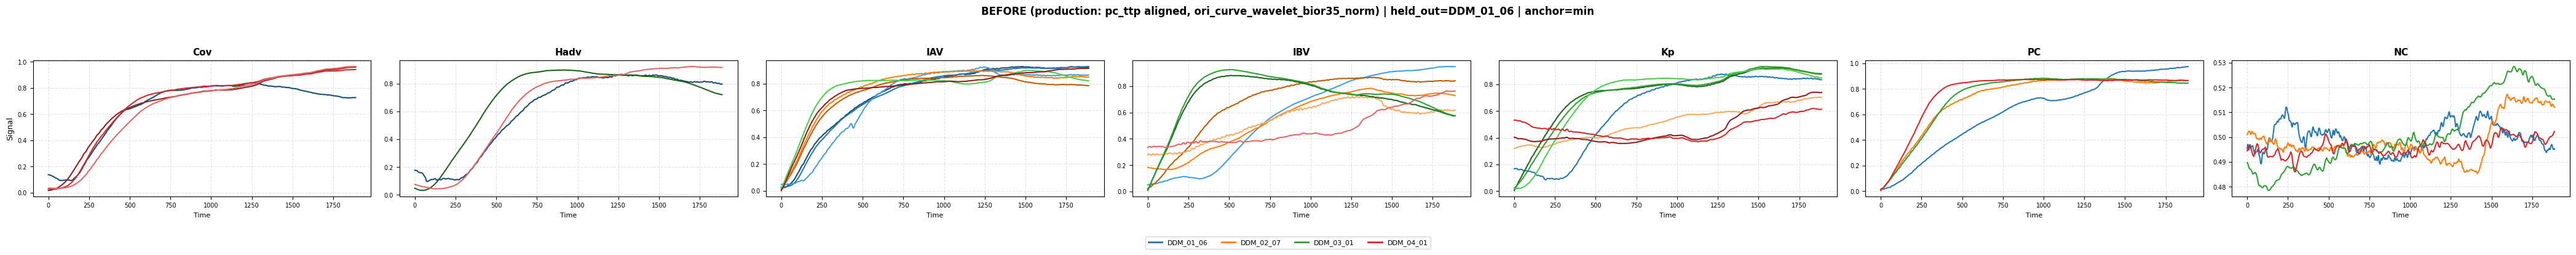

In [18]:
plot_target_across_chips(
    pool_norm,
    title=f"BEFORE (production: pc_ttp aligned, {CURVE_TYPE_NORM}) | held_out={short_name(HELD_OUT_CHIP)} | anchor={ANCHOR_METHOD}",
    with_all_curves=False,
)

## 5. Fit per-chip PC-based amplitude/shape calibration (on `pool_raw`, not yet normalized)

For each chip: take its own mean PC-well curve, and the mean PC-well curve of the
*other* chips as the reference (leave-one-chip-out, same leakage-safety convention
used everywhere else this session). Fit `a, b` by least squares so
`a * chip_pc_mean + b ~= reference_pc_mean`, then apply that same `(a, b)` to every
curve on that chip -- not just PC. Fit and applied on `pool_raw` (denoised, not yet
normalized), so real amplitude/gain differences between chips are still present for
the calibration to act on. Normalization is applied once, as the final step, after
calibration.

In [19]:
def fit_chip_calibration(pool, chip_names):
    pc_mask = pool["Y_mapped"] == "PC"
    calib = {}
    for chip in chip_names:
        chip_pc_mask = pc_mask & (pool["dataset_id"] == chip)
        other_pc_mask = pc_mask & (pool["dataset_id"] != chip)
        if chip_pc_mask.sum() == 0 or other_pc_mask.sum() == 0:
            calib[chip] = (1.0, 0.0)
            continue
        chip_pc_mean = pool["curves"][chip_pc_mask].mean(axis=0)
        ref_pc_mean = pool["curves"][other_pc_mask].mean(axis=0)
        a, b = np.polyfit(chip_pc_mean, ref_pc_mean, deg=1)
        calib[chip] = (float(a), float(b))
    return calib


def apply_calibration(pool, calib):
    after = dict(pool)
    curves = pool["curves"].copy()
    for chip, (a, b) in calib.items():
        m = pool["dataset_id"] == chip
        curves[m] = a * curves[m] + b
    after["curves"] = curves
    return after


calib = fit_chip_calibration(pool_raw, folder_names)
print("Fitted per-chip (a, b), on NOT-yet-normalized curves --")
print("a/b far from (1, 0) means the chip's PC amplitude/shape needed real rescaling:")
for chip, (a, b) in calib.items():
    print(f"  {short_name(chip)}: a={a:.4f}  b={b:.4f}")

after_raw = apply_calibration(pool_raw, calib)
after = dict(after_raw)
after["curves"] = cdt.normalize_curves_minmax(after_raw["curves"])   # normalize LAST, once

Fitted per-chip (a, b), on NOT-yet-normalized curves --
a/b far from (1, 0) means the chip's PC amplitude/shape needed real rescaling:
  DDM_01_06: a=0.4789  b=0.0080
  DDM_02_07: a=1.1411  b=0.0004
  DDM_03_01: a=1.0977  b=-0.0002
  DDM_04_01: a=1.0030  b=-0.0009


## 6. AFTER -- pc_ttp + PC-well amplitude/shape calibration, normalized last

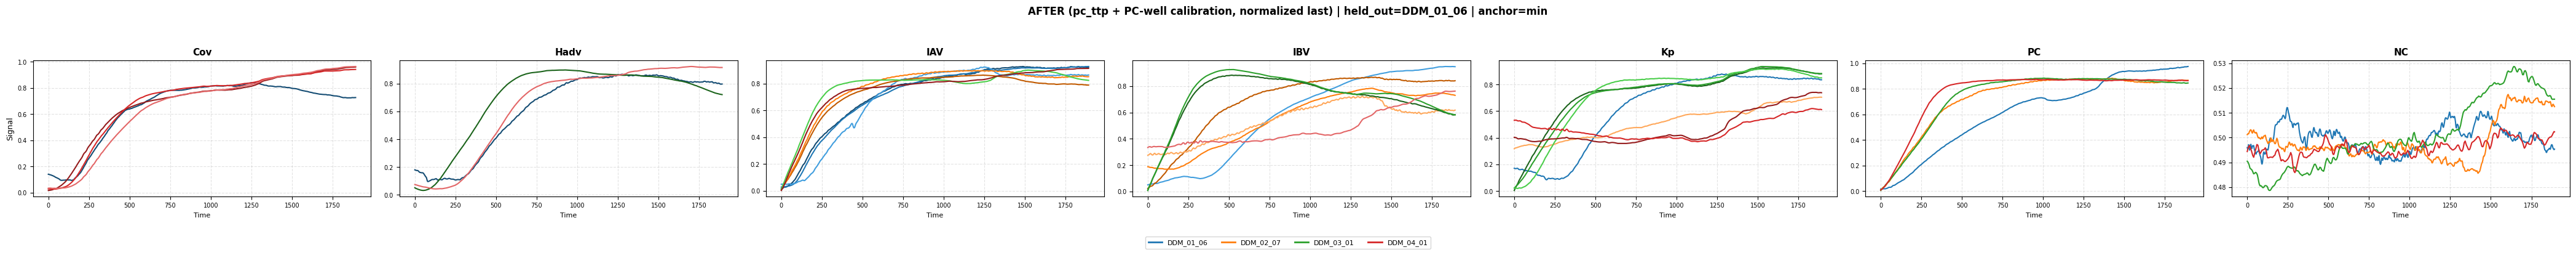

In [20]:
plot_target_across_chips(
    after,
    title=f"AFTER (pc_ttp + PC-well calibration, normalized last) | held_out={short_name(HELD_OUT_CHIP)} | anchor={ANCHOR_METHOD}",
    with_all_curves=False,
)

## 7. Quantitative check -- cross-chip spread before vs after

For each class: how far apart are the four chips' mean curves from their own grand
mean (lower = more converged). `ratio < 1` means calibration reduced cross-chip
spread for that class; `ratio >= 1` means it didn't help (or made it worse) --
watch `Kp`/`IBV` specifically, since those showed the clearest divergence in the
pc_ttp-only sweep. Both `before` and `after` are compared on the same [0,1]-normalized
scale (BEFORE = `pool_norm`, AFTER = calibrated-then-normalized) so the spread
numbers are directly comparable.

In [21]:
def spread_score(pool, label):
    mask = pool["Y_mapped"] == label
    chips = np.unique(pool["dataset_id"][mask])
    means = np.stack([pool["curves"][mask & (pool["dataset_id"] == c)].mean(axis=0) for c in chips])
    grand_mean = means.mean(axis=0)
    return float(np.mean((means - grand_mean) ** 2))


rows = []
for label in sorted(set(pool_norm["Y_mapped"])):
    b, a_ = spread_score(pool_norm, label), spread_score(after, label)
    rows.append({"label": label, "before": b, "after": a_, "ratio (after/before)": (a_ / b) if b else float("nan")})

pd.DataFrame(rows).set_index("label").sort_values("ratio (after/before)")

,before,after,ratio (after/before)
label,,,
Hadv,0.005224,0.005160,0.987768
Kp,0.023404,0.023414,1.000451
NC,0.000046,0.000046,1.000778
Cov,0.001967,0.001969,1.001178
IBV,0.026587,0.026625,1.001408
PC,0.007918,0.008031,1.014254
IAV,0.003489,0.003591,1.029411
